<a href="https://colab.research.google.com/github/munhyunsik/ML/blob/ML/week9_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [25]:
train_data = pd.read_csv('/content/train.csv')
test_data = pd.read_csv('/content/test.csv')

In [26]:
x = train_data.iloc[:, 1:].values
y = train_data.iloc[:, 0].values

In [27]:
x = x / 255.0
x = x.reshape(-1,28,28,1)

In [33]:
x = x.reshape(x.shape[0], -1)

In [35]:
x.shape

(42000, 784)

In [36]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, shuffle=True
)


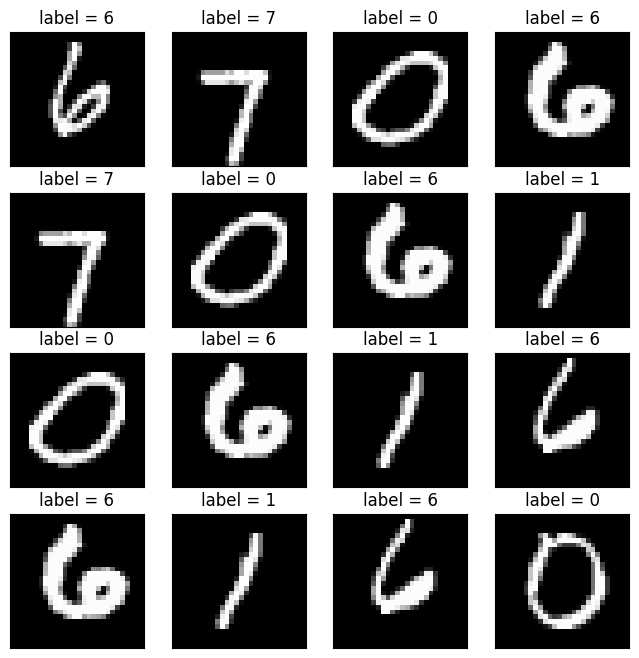

In [37]:
fig, ax = plt.subplots(4,4, figsize = (8,8))
for i in range(4):
  for j in range(4):
    ax[i,j].imshow(x_train[i*4+j*4].reshape(28,28), cmap = 'gray')
    ax[i,j].set_title('label = %s' % (y_train[i*4 + j*4]))
    ax[i,j].set_xticks([])
    ax[i,j].set_yticks([])

In [38]:
from sklearn.linear_model import LogisticRegression


In [39]:
clf = LogisticRegression(C = 1.0, class_weight = None, dual = False, fit_intercept = True,
                         intercept_scaling= 1 , l1_ratio= None, max_iter= 100, multi_class='multinomial'
                         , n_jobs= None, penalty= 'l2', random_state= None, solver = 'lbfgs', tol = 0.001,
                         verbose = 0, warm_start= False)

In [40]:
clf.fit(x_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial', tol=0.001)

In [41]:
from sklearn.metrics import accuracy_score

In [42]:
y_val_pred = clf.predict(x_val)
print("Model accuracy is %0.3f" % (accuracy_score(y_val, y_val_pred)))

Model accuracy is 0.919


In [43]:
x_val_correct = x_val[y_val == y_val_pred, : ]
y_val_correct = y_val[y_val == y_val_pred]
y_val_pred_correct = y_val_pred[y_val == y_val_pred]

Correctly predicted images : 


Correctly predicted images : 


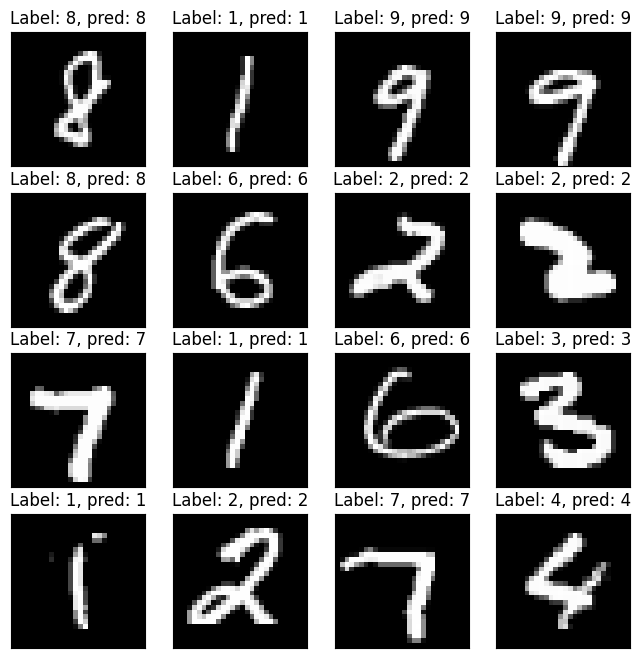

In [47]:
print("Correctly predicted images : ")

fig, ax = plt.subplots(4, 4, figsize=(8, 8))

for i in range(4):
    for j in range(4):
        idx = i * 4 + j

        ax[i, j].imshow(x_val_correct[idx].reshape(28, 28), cmap='gray')
        ax[i, j].set_title(f'Label: {y_val_correct[idx]}, pred: {y_val_pred_correct[idx]}')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])




In [48]:
x_val_incorrect = x_val[y_val != y_val_pred, :]
y_val_incorrect = y_val[y_val != y_val_pred]
y_val_pred_incorrect = y_val_pred[y_val != y_val_pred]

Inorrectly predicted images : 


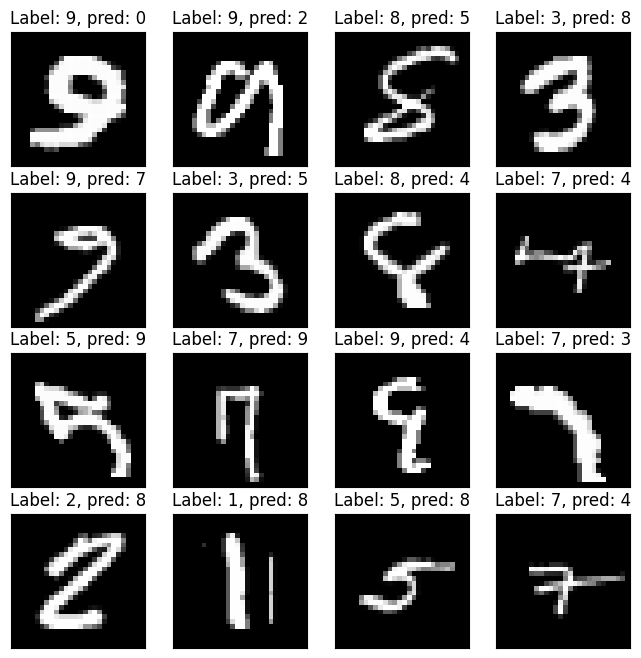

In [49]:
print("Inorrectly predicted images : ")

fig, ax = plt.subplots(4, 4, figsize=(8, 8))

for i in range(4):
    for j in range(4):
        idx = i * 4 + j

        ax[i, j].imshow(x_val_incorrect[idx].reshape(28, 28), cmap='gray')
        ax[i, j].set_title(f'Label: {y_val_incorrect[idx]}, pred: {y_val_pred_incorrect[idx]}')
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])

In [54]:
x_test = test_data.values
x_test = x_test / 255.0
x_test = x_test.reshape(-1,28,28,1)
x_test = x_test.reshape(x_test.shape[0], -1)

In [55]:
x_test.shape

(28000, 784)

In [56]:
preds = clf.predict(x_test)

In [58]:
sample_submission = pd.read_csv('/content/sample_submission.csv')
sample_submission['Label'] = preds
sample_submission.to_csv('/content/sample_submission.csv', index = False)